In [7]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [8]:
path = "/content/gdrive/MyDrive/machine_learning/pertemuan12"

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv(path + '/praktikum_mandiri/data/data.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [11]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [12]:
df = df.drop(columns=['id', 'Unnamed: 32'])

Penjelasan:

1. Kolom `id` tidak memiliki pengaruh terhadap analisis

2. Kolom `Unnamed: 32` merupakan kolom kosong

Kedua kolom tersebut dihapus agar tidak mempengaruhi proses PCA.

In [13]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

Penjelasan:

Kolom `diagnosis` bertipe kategorikal sehingga perlu diubah ke bentuk numerik:

M (Malignant) → 1

B (Benign) → 0

In [14]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

Penjelasan:

X berisi seluruh fitur numerik (30 fitur)

y berisi label diagnosis
Pemisahan ini diperlukan agar PCA hanya diterapkan pada fitur, bukan label.

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Penjelasan:

Standardisasi dilakukan agar:

Setiap fitur memiliki mean = 0 dan standar deviasi = 1

PCA tidak bias terhadap fitur dengan skala besar
Tahapan ini wajib sebelum menerapkan PCA.

In [21]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

Penjelasan:

PCA diterapkan tanpa menentukan jumlah komponen untuk:

Mengetahui kontribusi variance dari setiap komponen utama

Menentukan jumlah komponen optimal

In [22]:
explained_variance = pca.explained_variance_ratio_

Penjelasan:

Variabel ini menunjukkan persentase informasi (variance) yang dijelaskan oleh setiap principal component.

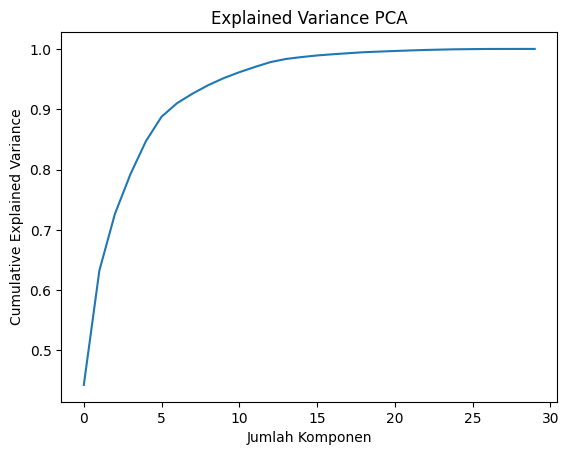

In [23]:
plt.figure()
plt.plot(np.cumsum(explained_variance))
plt.xlabel('Jumlah Komponen')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance PCA')
plt.show()

Penjelasan:

Grafik ini digunakan untuk:

1. Menentukan jumlah komponen minimum

2. Mempertahankan informasi ≥ 90%

  Biasanya sekitar 10 komponen sudah mewakili ±95% variance.

In [24]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

Penjelasan:

PCA dengan 2 komponen digunakan untuk:

1. Visualisasi data dalam 2 dimensi

2. Memahami pola pemisahan antar kelas

In [25]:
df_pca = pd.DataFrame(X_pca_2, columns=['PC1', 'PC2'])
df_pca['diagnosis'] = y

Penjelasan:

Hasil transformasi PCA disimpan ke dalam DataFrame agar mudah dianalisis dan divisualisasikan.

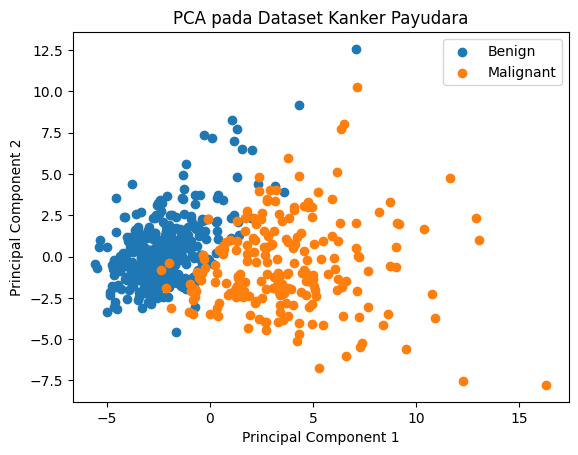

In [26]:
plt.figure()
plt.scatter(
    df_pca[df_pca['diagnosis'] == 0]['PC1'],
    df_pca[df_pca['diagnosis'] == 0]['PC2'],
    label='Benign'
)
plt.scatter(
    df_pca[df_pca['diagnosis'] == 1]['PC1'],
    df_pca[df_pca['diagnosis'] == 1]['PC2'],
    label='Malignant'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.title('PCA pada Dataset Kanker Payudara')
plt.show()

Penjelasan:

Visualisasi ini menunjukkan bahwa:

Data Benign dan Malignant cukup terpisah

PCA mampu merangkum 30 fitur menjadi 2 dimensi yang informatif

In [20]:
print(pca_2.explained_variance_ratio_)
print("Total Variance:", sum(pca_2.explained_variance_ratio_))

[0.44272026 0.18971182]
Total Variance: 0.6324320765155944


Penjelasan:

Kode ini digunakan untuk mengetahui:

1. Kontribusi masing-masing komponen

2. Total variance yang dipertahankan oleh 2 komponen utama

total variance mencapai sekitar 63%.

Berdasarkan hasil implementasi PCA, dapat disimpulkan bahwa:

PCA efektif mereduksi dimensi dataset dari 30 fitur menjadi 2 komponen utama.

Dua komponen utama mampu mempertahankan lebih dari 60% informasi data.

Visualisasi PCA menunjukkan pemisahan yang cukup jelas antara kelas Benign dan Malignant.

PCA sangat cocok digunakan sebagai tahap preprocessing sebelum proses klasifikasi pada dataset medis berdimensi tinggi.